In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('PC_Gamer.csv', sep=';')
df.head()

,Item,Descricao,Preco,Data
0,CPU,AMD Ryzen 5 5600GT,1032.93,2026-06-04
1,Motherboard,Chronos B550M-CR,647.05,2026-06-04
2,RAM,2x Hyper X Fury DDR4 8GB 3200 MHz,548.21,2026-06-04
3,Gabinete,C3tech Aquarius,299.83,2026-06-04
4,Mouse,Attack Shark Wireless X11,114.29,2026-06-04


In [4]:
itens = df.groupby('Item')
itens

In [5]:
# Armazenar em dicionário
df_itens = {item: group.copy() for item, group in itens}
df_itens

{'CPU':    Item           Descricao    Preco        Data
 0   CPU  AMD Ryzen 5 5600GT  1032.93  2026-06-04
 7   CPU  AMD Ryzen 5 5600GT  1032.93  2026-06-09
 14  CPU  AMD Ryzen 5 5600GT  1031.76  2026-06-15,
 'Gabinete':         Item        Descricao   Preco        Data
 3   Gabinete  C3tech Aquarius  299.83  2026-06-04
 10  Gabinete  C3tech Aquarius  299.83  2026-06-09
 17  Gabinete  C3tech Aquarius  299.83  2026-06-15,
 'Headset':        Item          Descricao  Preco        Data
 5   Headset  BINNUNE Bluetooth  93.11  2026-06-04
 12  Headset  BINNUNE Bluetooth  99.76  2026-06-09
 19  Headset  BINNUNE Bluetooth  99.58  2026-06-15,
 'Motherboard':            Item         Descricao   Preco        Data
 1   Motherboard  Chronos B550M-CR  647.05  2026-06-04
 8   Motherboard  Chronos B550M-CR  647.05  2026-06-09
 15  Motherboard  Chronos B550M-CR  647.05  2026-06-15,
 'Mouse':      Item                  Descricao   Preco        Data
 4   Mouse  Attack Shark Wireless X11  114.29  2026-06-0

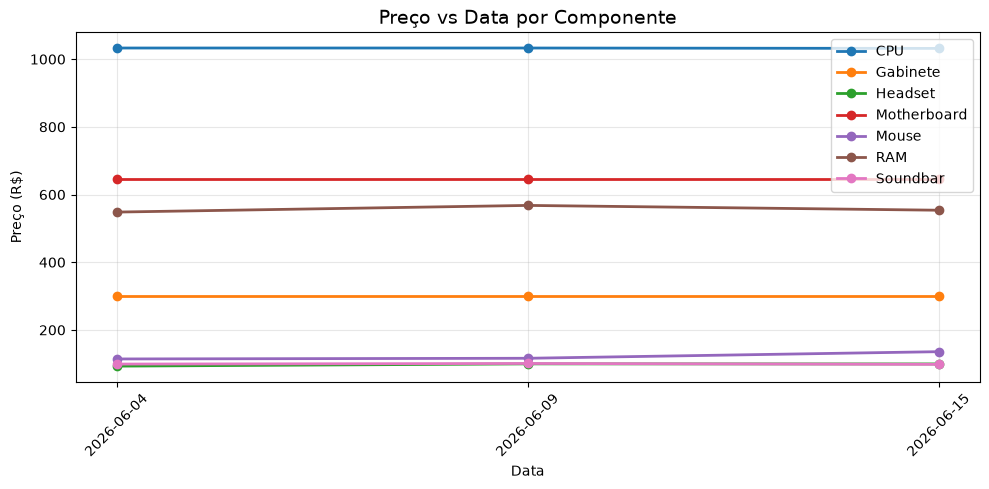

In [8]:
# Plotar todos no mesmo gráfico
plt.figure(figsize=(10, 5))

for item, df_item in df_itens.items():
    plt.plot(df_item['Data'], df_item['Preco'], marker='o', label=item, linewidth=2)

plt.title('Preço vs Data por Componente', fontsize=14)
plt.xlabel('Data')
plt.ylabel('Preço (R$)')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
import seaborn as sns
from datetime import datetime

In [8]:
# Configurar estilo dos gráficos
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 8)

In [9]:
# 1. Ler o arquivo CSV
df = pd.read_csv('PC_Gamer.csv', sep=';', encoding='utf-8-sig', parse_dates=['Data'])

print("Dados carregados:")
print(df.head())
print(f"\nShape: {df.shape}")
print(f"Tipos de item únicos: {df['Item'].unique()}")

Dados carregados:
          Item                          Descricao    Preco       Data
0          CPU                 AMD Ryzen 5 5600GT  1032.93 2026-06-04
1  Motherboard                   Chronos B550M-CR   647.05 2026-06-04
2          RAM  2x Hyper X Fury DDR4 8GB 3200 MHz   548.21 2026-06-04
3     Gabinete                    C3tech Aquarius   299.83 2026-06-04
4        Mouse          Attack Shark Wireless X11   114.29 2026-06-04

Shape: (21, 4)
Tipos de item únicos: <StringArray>
['CPU', 'Motherboard', 'RAM', 'Gabinete', 'Mouse', 'Headset', 'Soundbar']
Length: 7, dtype: str


In [10]:
# 2. Agrupar por Item e armazenar em variáveis
# Criar um dicionário para armazenar os DataFrames de cada item
df_itens = {}

for item in df['Item'].unique():
    df_itens[item] = df[df['Item'] == item].copy()
    df_itens[item] = df_itens[item].sort_values('Data')  # Ordenar por data
    print(f"\n{item}: {len(df_itens[item])} registros")
    print(df_itens[item][['Data', 'Preco']].to_string(index=False))


CPU: 3 registros
      Data   Preco
2026-06-04 1032.93
2026-06-09 1032.93
2026-06-15 1031.76

Motherboard: 3 registros
      Data  Preco
2026-06-04 647.05
2026-06-09 647.05
2026-06-15 647.05

RAM: 3 registros
      Data  Preco
2026-06-04 548.21
2026-06-09 567.91
2026-06-15 553.70

Gabinete: 3 registros
      Data  Preco
2026-06-04 299.83
2026-06-09 299.83
2026-06-15 299.83

Mouse: 3 registros
      Data  Preco
2026-06-04 114.29
2026-06-09 116.30
2026-06-15 135.81

Headset: 3 registros
      Data  Preco
2026-06-04  93.11
2026-06-09  99.76
2026-06-15  99.58

Soundbar: 3 registros
      Data  Preco
2026-06-04  99.20
2026-06-09 100.92
2026-06-15  98.32


In [14]:
# Acessar cada item individualmente (se preferir variáveis separadas)
cpu_df = df_itens['CPU']
motherboard_df = df_itens['Motherboard']
ram_df = df_itens['RAM']
gabinete_df = df_itens['Gabinete']
mouse_df = df_itens['Mouse']
headset_df = df_itens['Headset']
soundbar_df = df_itens['Soundbar']

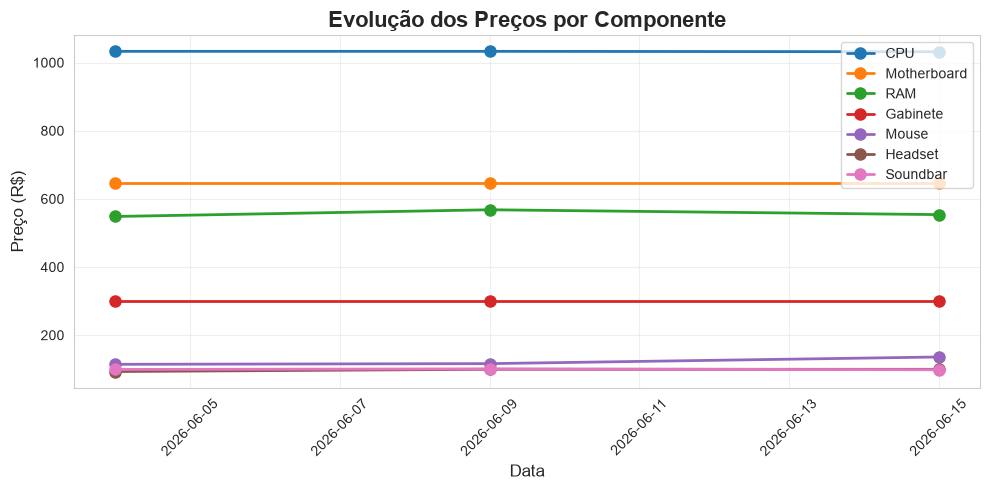

In [16]:
# 3. Plotar gráfico: Preço vs Data para cada tipo de item

# Opção 1: Todos os itens no mesmo gráfico (recomendado para comparação)
plt.figure(figsize=(10, 5))

for item, df_item in df_itens.items():
    plt.plot(df_item['Data'], df_item['Preco'], 
             marker='o', 
             label=item, 
             linewidth=2, 
             markersize=8)

plt.title('Evolução dos Preços por Componente', fontsize=16, fontweight='bold')
plt.xlabel('Data', fontsize=12)
plt.ylabel('Preço (R$)', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

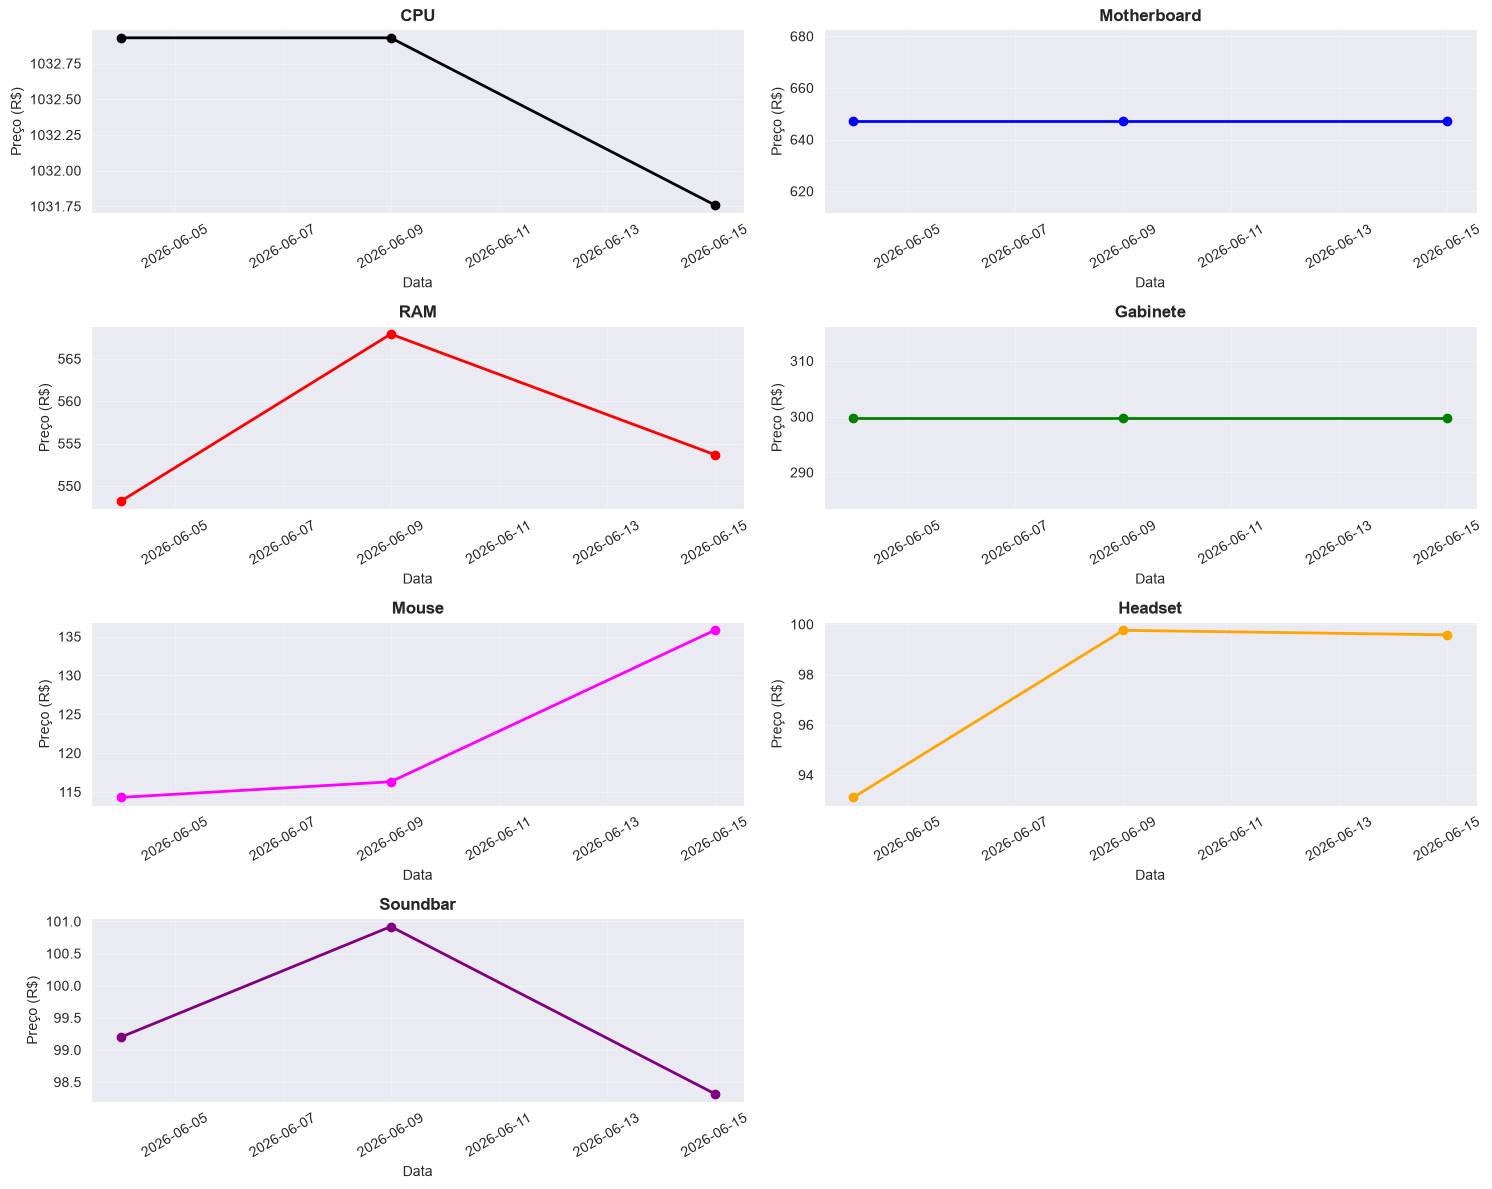

In [13]:
# Opção 2: Gráficos separados para cada item (subplots)
fig, axes = plt.subplots(4, 2, figsize=(15, 12))
axes = axes.flatten()

cores = ['black', 'blue', 'red', 'green', 'magenta', 'orange', 'purple']

for idx, (item, df_item) in enumerate(df_itens.items()):
    if idx < len(axes):
        cor = cores[idx % len(cores)]

        axes[idx].plot(df_item['Data'], df_item['Preco'], 
                       marker='o', 
                       linewidth=2, 
                       markersize=6,
                       color=cor)
        axes[idx].set_title(f'{item}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Data', fontsize=10)
        axes[idx].set_ylabel('Preço (R$)', fontsize=10)
        axes[idx].grid(True, alpha=0.3)
        axes[idx].tick_params(axis='x', rotation=30)

# Remover subplots vazios (se houver menos de 8 itens)
for idx in range(len(df_itens), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()

data_atual = datetime.now().strftime('%Y-%m-%d')
plt.savefig(f'plots/pcgamer_prices_{data_atual}.png')

plt.show()